In [1]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report , confusion_matrix , accuracy_score
from sklearn.tree import plot_tree
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv("heart.csv")
print(dataset.head())
print(dataset.target.unique())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
[0 1]


In [3]:
x = dataset.drop('target' , axis = 1)
y = dataset['target']

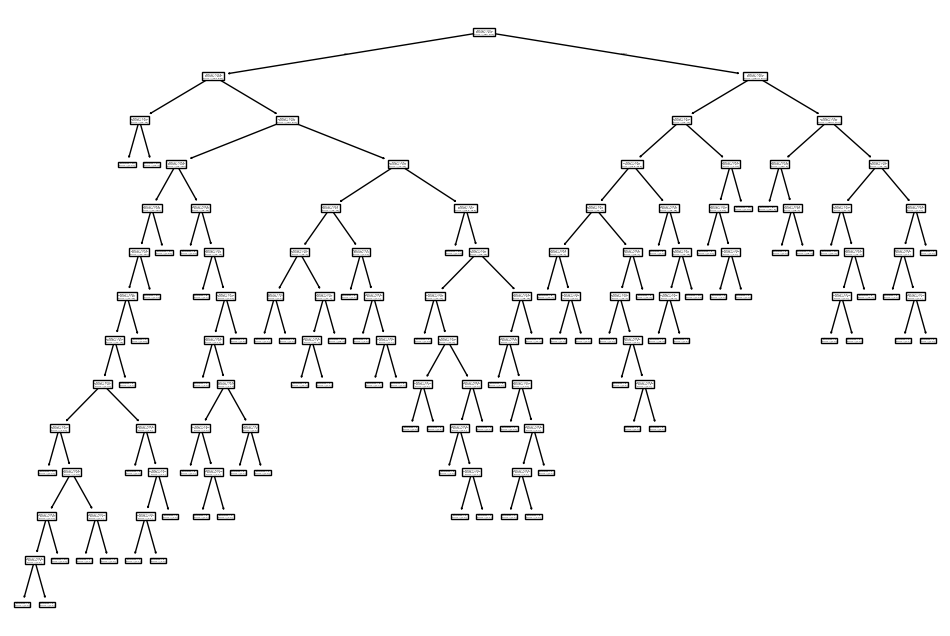

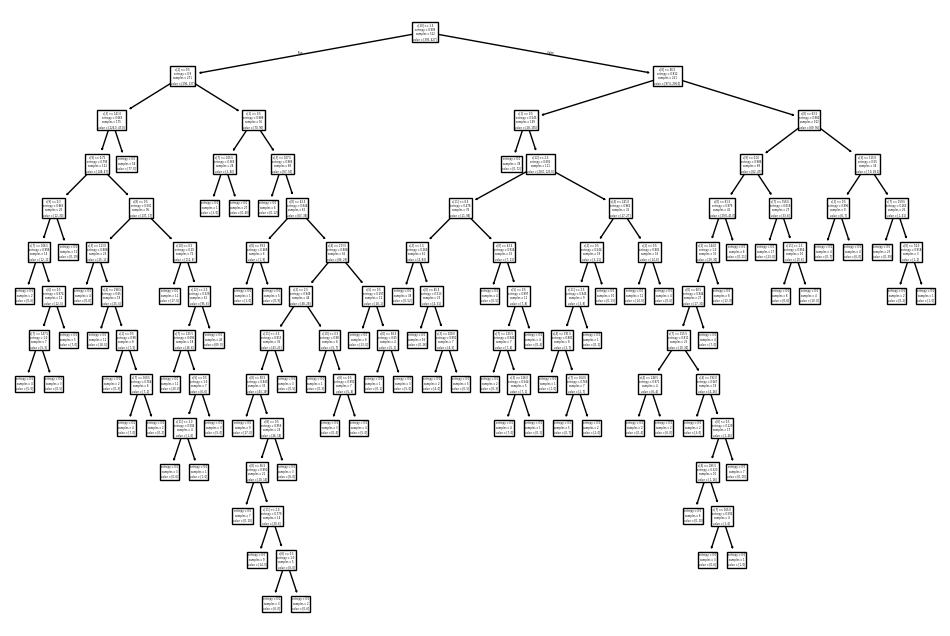

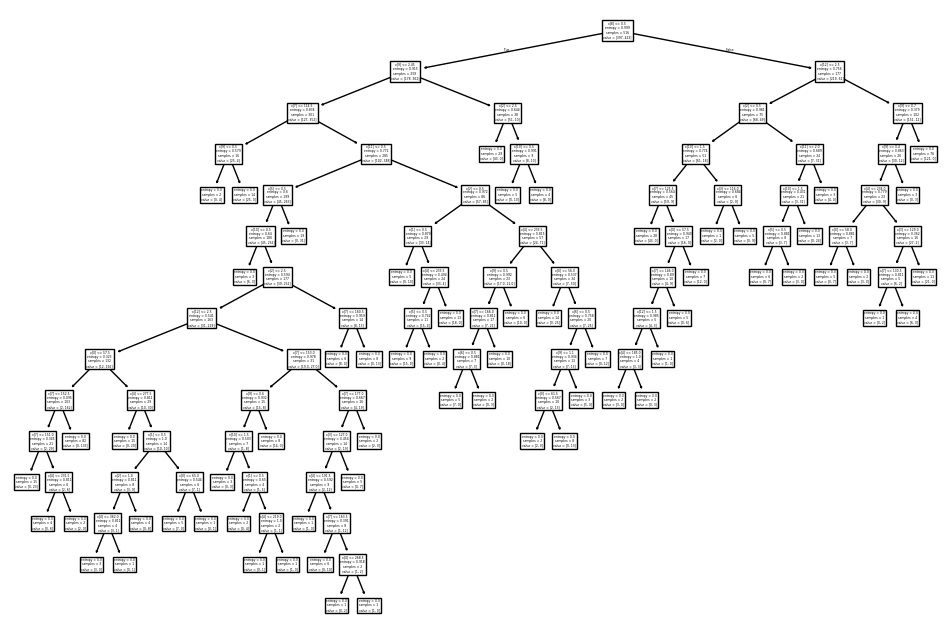

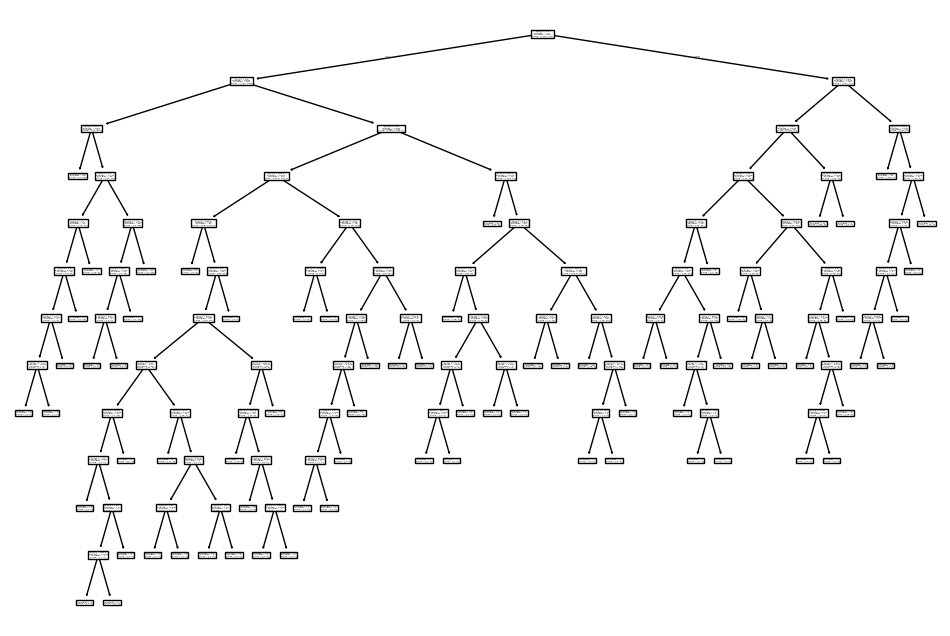

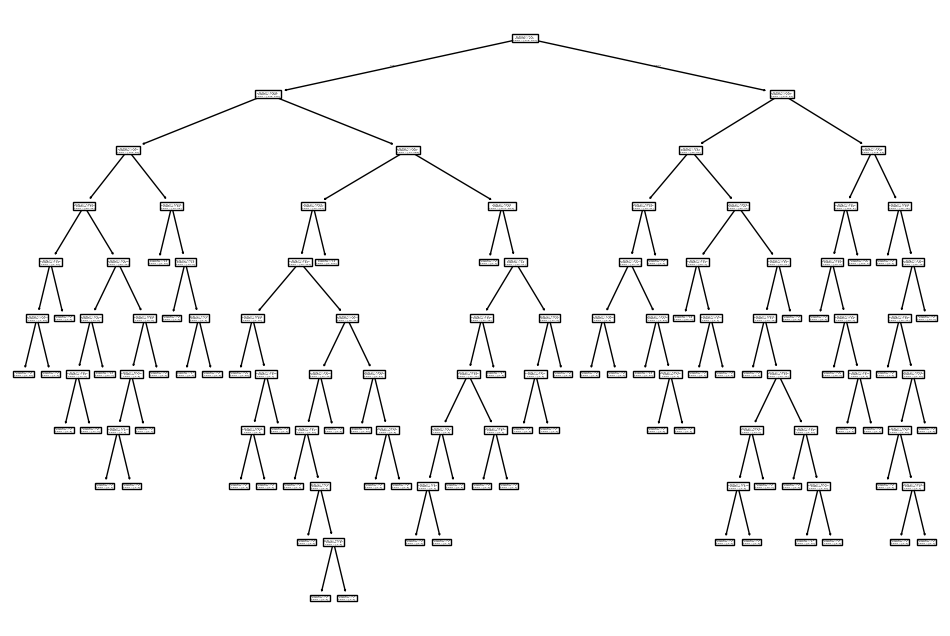

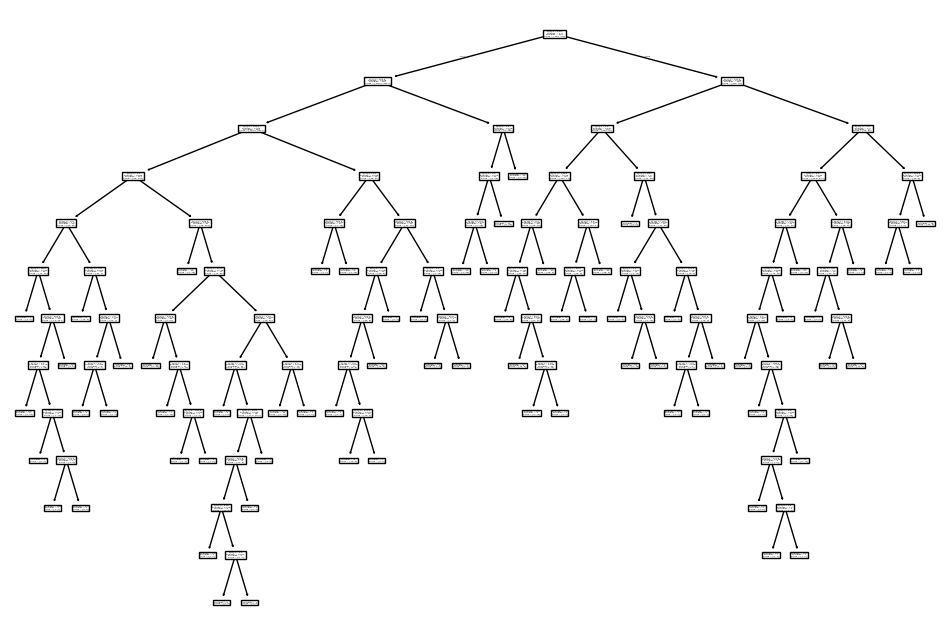

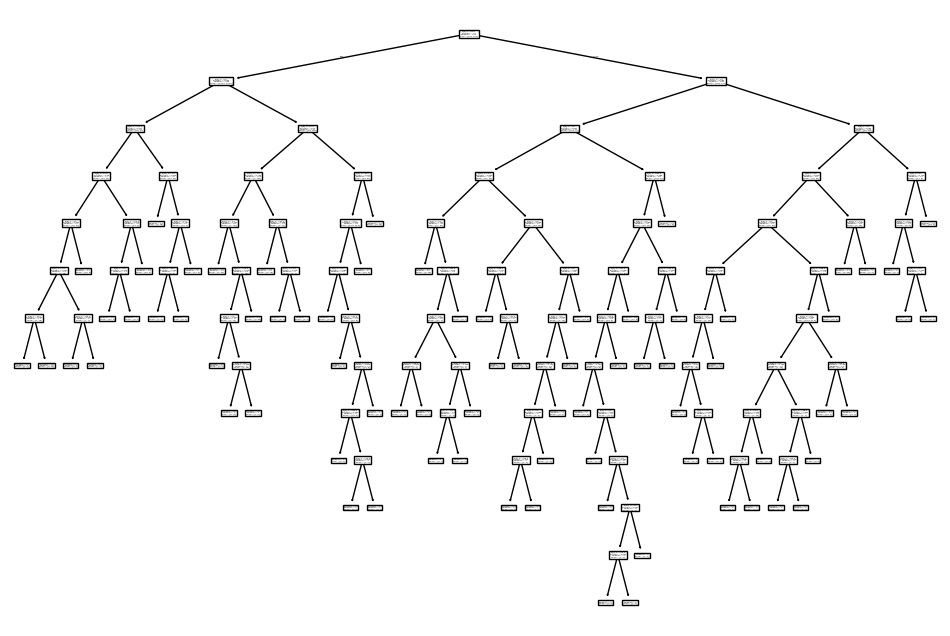

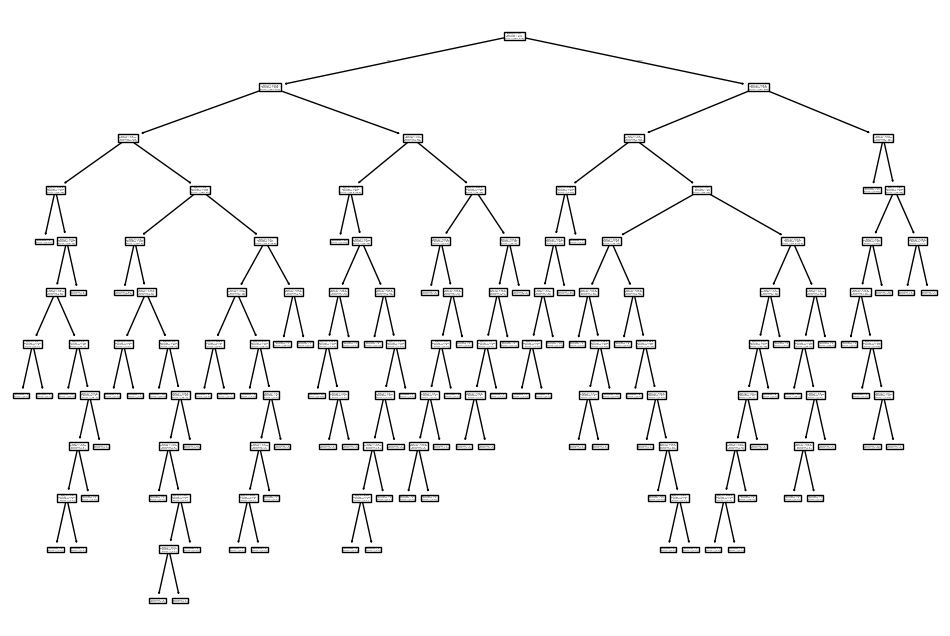

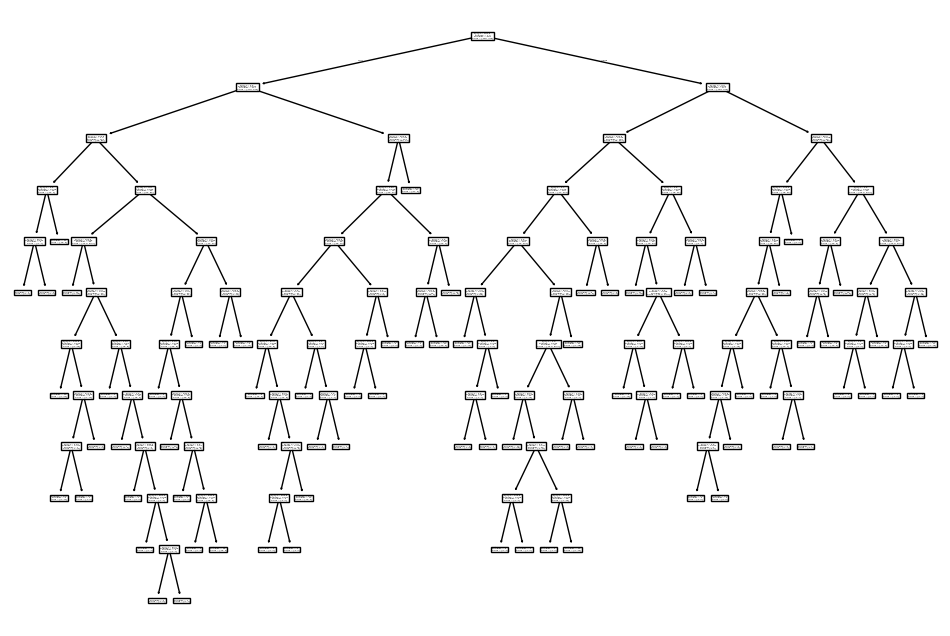

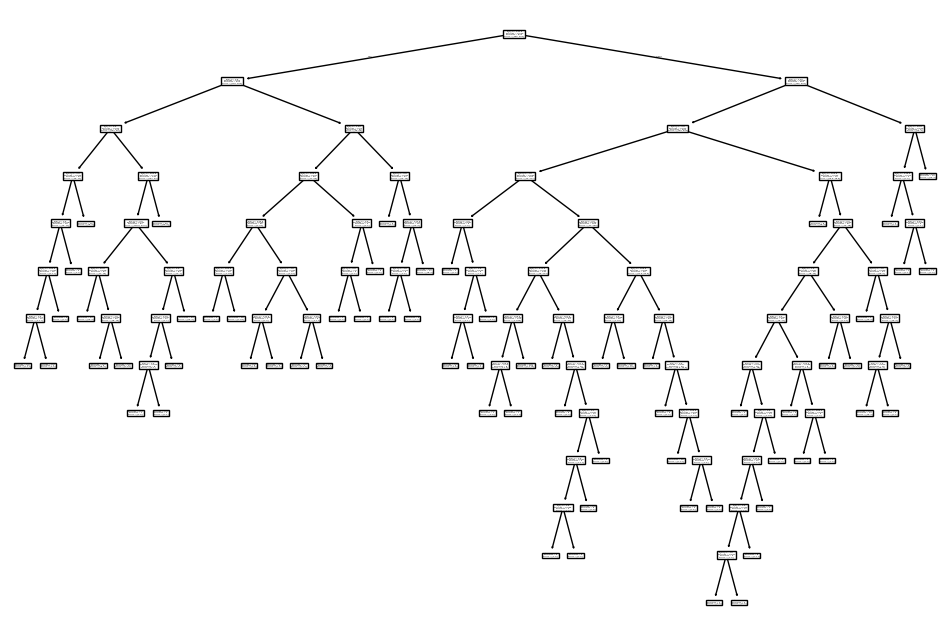

In [4]:
x_train , x_test , y_train , y_test = train_test_split(x , y ,test_size = 0.2)
model = RandomForestClassifier(n_estimators = 10 , criterion = 'entropy')
model.fit(x_train , y_train)
for i in range (10) :
    plt.figure(figsize=(12,8))
    plot_tree(model.estimators_[i])
    plt.show()

In [5]:
y_pred = model.predict(x_test)
validating = x_test.copy()

validating['Actual y_test'] = y_test.squeeze()
validating['predicted y_pred'] = y_pred.squeeze()
pd.set_option('display.max_rows' , 500)
pd.set_option('display.max_columns' , 500)
pd.set_option('display.width' , 500)
print(validating)

      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal  Actual y_test  predicted y_pred
55     55    1   0       140   217    0        1      111      1      5.6      0   0     3              0                 0
282    41    0   1       130   204    0        0      172      0      1.4      2   0     2              1                 1
679    68    1   2       180   274    1        0      150      1      1.6      1   0     3              0                 0
735    50    1   2       129   196    0        1      163      0      0.0      2   0     2              1                 1
489    61    1   2       150   243    1        1      137      1      1.0      1   0     2              1                 1
660    61    1   0       138   166    0        0      125      1      3.6      1   1     2              0                 0
525    51    0   2       130   256    0        0      149      0      0.5      2   0     2              1                 1
203    6

In [6]:
print("Confusin Matrix :- \n" , confusion_matrix(y_pred , y_test))
print("Accuracy Score :- \n" , accuracy_score(y_pred , y_test))
print("Classification Report :- \n" , classification_report(y_pred , y_test))

Confusin Matrix :- 
 [[102   0]
 [  0 103]]
Accuracy Score :- 
 1.0
Classification Report :- 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       102
           1       1.00      1.00      1.00       103

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205

